<a href="https://colab.research.google.com/github/hongxu-yn/Drought-monitoring-and-assessment/blob/main/%E5%B9%B4%E5%92%8C%E5%AD%A3%E8%8A%82%E6%80%A7%E5%B9%B2%E6%97%B1%E4%B8%8E%E6%A4%8D%E8%A2%ABNDVIS%E7%9B%B8%E5%85%B3%E5%88%86%E6%9E%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from google.colab import drive
!pip install -q netCDF4 joblib tqdm xarray pykrige gstools cartopy scipy regionmask

drive.mount('/content/drive')
print("✅ Drive mounted successfully and environment initialization complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.5/129.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.3 MB/s eta 0:00:00
Mounted at /content/drive
✅ Drive mounted successfully and environment initialization complete!


In [36]:
import xarray as xr

nc_fn = "/content/drive/MyDrive/DATA/Satellite/ndvi_month_2001_2025.nc"
target_fn = "/content/drive/MyDrive/Drought-monitoring-and-assessment/data/spei/year/spei_year_2001_2025.nc"
out_fn = project_dir / "data/ndvi/ndvi_month_2001_2025.nc"

ds = xr.open_dataset(nc_fn)
target = xr.open_dataset(target_fn)

ds_resized = ds.interp(
    lon=target["lon"],
    lat=target["lat"],
    method="linear"
)
ds_resized=ds_resized*10000
ds_resized.to_netcdf(out_fn)
print(f"已保存: {out_fn}")

已保存: /content/drive/MyDrive/Drought-monitoring-and-assessment/data/ndvi/ndvi_month_2001_2025.nc


In [46]:
project_dir = Path('/content/drive/MyDrive/Drought-monitoring-and-assessment')
nc_fn = project_dir / "data/ndvi/ndvi_month_2001_2025.nc"
output_dir = project_dir / "data/ndvi"
output_dir.mkdir(parents=True, exist_ok=True)

ds = xr.open_dataset(nc_fn)
var = list(ds.data_vars)[0]

month = ds.time.dt.month
year = ds.time.dt.year
ds.coords["season_year"] = xr.where(month == 12, year + 1, year)

annual = ds.resample(time="YS").mean()
spring = ds.where(month.isin([3, 4, 5]), drop=True).groupby("season_year").mean("time")
summer = ds.where(month.isin([6, 7, 8]), drop=True).groupby("season_year").mean("time")
autumn = ds.where(month.isin([9, 10, 11]), drop=True).groupby("season_year").mean("time")
winter = ds.where(month.isin([12, 1, 2]), drop=True).groupby("season_year").mean("time")

def finalize_seasonal_ds(d):
    # groupby 之后，原来的 "season_year" 变成了维度 "season_year"
    d.coords["season_year"] = pd.to_datetime(d.season_year.values.astype(int), format="%Y")
    return d.rename({"season_year": "time"})

spring = finalize_seasonal_ds(spring)
summer = finalize_seasonal_ds(summer)
autumn = finalize_seasonal_ds(autumn)

winter = finalize_seasonal_ds(winter)
winter = winter.assign_coords(
    time=pd.to_datetime((winter.time.dt.year.values - 1).astype(str), format="%Y")
)
winter = winter.sel(time=slice("2001-01-01", "2024-01-01"))

# 7. 保存文件
spring.to_netcdf(output_dir / "ndvi_spring_2001_2025.nc")
summer.to_netcdf(output_dir / "ndvi_summer_2001_2025.nc")
autumn.to_netcdf(output_dir / "ndvi_autumn_2001_2025.nc")
winter.to_netcdf(output_dir / "ndvi_winter_2001_2024.nc")
annual.to_netcdf(output_dir / "ndvi_year_2001_2025.nc")

print(f"处理完成！所有文件已保存至: {output_dir}")

处理完成！所有文件已保存至: /content/drive/MyDrive/Drought-monitoring-and-assessment/data/ndvi


# 去趋势

In [75]:
from pathlib import Path
import xarray as xr
import pandas as pd
import numpy as np
import warnings
from numpy.polynomial.polyutils import RankWarning

def get_time_dim(da):
    for d in da.dims:
        if "time" in d.lower():
            return d
    raise ValueError(f"未找到时间维，当前 dims={da.dims}")

def detrend_1d(y):
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(y)
    if mask.sum() < 3:
        return y
    if np.nanstd(y[mask]) < 1e-6:
        return y
    x = np.arange(mask.sum(), dtype=float)
    yy = y[mask]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RankWarning)
        coef = np.polyfit(x, yy, 1)
    trend = np.polyval(coef, x)
    out = y.copy()
    out[mask] = yy - trend + np.nanmean(yy)
    return out

def detrend_data(da, dim="time"):
    return xr.apply_ufunc(
        detrend_1d,
        da,
        input_core_dims=[[dim]],
        output_core_dims=[[dim]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float]
    )

project_dir = Path('/content/drive/MyDrive/Drought-monitoring-and-assessment')
nc_fn = project_dir / "data/ndvi/ndvi_month_2001_2025.nc"
output_dir = project_dir / "data/sai"
output_dir.mkdir(parents=True, exist_ok=True)

ds = xr.open_dataset(nc_fn)

time_dim = get_time_dim(da)

month = da[time_dim].dt.month
year = da[time_dim].dt.year
da = da.assign_coords(season_year=xr.where(month == 12, year + 1, year))

annual = da.resample({time_dim: "YS"}).mean()

spring = da.where(month.isin([3, 4, 5]), drop=True).groupby("season_year").mean(time_dim)
summer = da.where(month.isin([6, 7, 8]), drop=True).groupby("season_year").mean(time_dim)
autumn = da.where(month.isin([9, 10, 11]), drop=True).groupby("season_year").mean(time_dim)
winter = da.where(month.isin([12, 1, 2]), drop=True).groupby("season_year").mean(time_dim)

def finalize_and_detrend(da):
    if "season_year" in da.dims:
        da = da.assign_coords(
            season_year=pd.to_datetime(da["season_year"].values.astype(int), format="%Y")
        ).rename({"season_year": "time"})
    elif time_dim != "time":
        da = da.rename({time_dim: "time"})
    return detrend_data(da, dim="time")

spring_detrend = finalize_and_detrend(spring)
summer_detrend = finalize_and_detrend(summer)
autumn_detrend = finalize_and_detrend(autumn)
annual_detrend = finalize_and_detrend(annual)

winter_detrend = finalize_and_detrend(winter)
winter_detrend = winter_detrend.assign_coords(
    time=pd.to_datetime((winter_detrend["time"].dt.year.values - 1).astype(str), format="%Y")
)
winter_detrend = winter_detrend.sel(time=slice("2001-01-01", "2024-01-01"))

spring_detrend.to_netcdf(output_dir / "sai_spring_2001_2025.nc")
summer_detrend.to_netcdf(output_dir / "sai_summer_2001_2025.nc")
autumn_detrend.to_netcdf(output_dir / "sai_autumn_2001_2025.nc")
winter_detrend.to_netcdf(output_dir / "sai_winter_2001_2024.nc")
annual_detrend.to_netcdf(output_dir / "sai_year_2001_2025.nc")

print(f"处理完成！去趋势后的数据已保存至: {output_dir}")

处理完成！去趋势后的数据已保存至: /content/drive/MyDrive/Drought-monitoring-and-assessment/data/sai


# SPEI 格点化

In [30]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
import xarray as xr
import os
from pathlib import Path
project_dir= Path('/content/drive/MyDrive/Drought-monitoring-and-assessment')
path_station = project_dir/ 'data/站点编号及信息_选定_1969-2025.xlsx'
path_spei = project_dir / 'data/spei/SPEI_month_1969_2025.csv'


df_stations = pd.read_excel(path_station)
spei_df = pd.read_csv(path_spei)
spei_df = spei_df[spei_df['year'].between(2001, 2026)]
combined_df = pd.merge(spei_df, df_stations[['station', 'lat', 'lon']], on='station', how='inner')

# 4. 定义插值网格 (20-30N, 97-107E, Res: 0.05)
res = 0.05
lon_coords = np.arange(97.0, 107.0 + res, res)
lat_coords = np.arange(20.0, 30.0 + res, res)
grid_lon, grid_lat = np.meshgrid(lon_coords, lat_coords)
grid_points = np.column_stack((grid_lon.ravel(), grid_lat.ravel()))


def idw_func(x, y, z, target_pts, p=2):
    known_pts = np.column_stack((x, y))
    dist = cdist(target_pts, known_pts)
    dist = np.where(dist == 0, 1e-10, dist)
    weights = 1.0 / (dist ** p)
    return np.sum(weights * z, axis=1) / np.sum(weights, axis=1)

combined_df['time'] = pd.to_datetime(combined_df[['year', 'month']].assign(day=1))
time_steps = sorted(combined_df['time'].unique())
results = np.zeros((len(time_steps), len(lat_coords), len(lon_coords)))

print(f"开始插值，共 {len(time_steps)} 个月份...")

# 外层循环：支持未来批量处理多个尺度，例如 [1, 3, 6, 12]
for time_scale in range (1,13):
    field_name = f'SPEI{time_scale}_Month'
    output_nc = f'/content/drive/MyDrive/Drought-monitoring-and-assessment/data/spei/SPEI{time_scale:02d}_month_2001_2025.nc'

    results = np.full((len(time_steps), len(lat_coords), len(lon_coords)), np.nan)

    for i, t in enumerate(time_steps):
        curr_df = combined_df[combined_df['time'] == t].dropna(subset=[field_name, 'lat', 'lon'])

        if not curr_df.empty:
            z_grid = idw_func(curr_df['lon'].values, curr_df['lat'].values,
                              curr_df[field_name].values, grid_points)

            results[i, :, :] = z_grid.reshape(len(lat_coords), len(lon_coords))
        else:
            print(f"警告：{pd.to_datetime(t).strftime('%Y-%m')} 缺失全部站点数据，记为 NaN")

        if (i+1) % 120 == 0:
            print(f"进度 ({field_name}): 已完成 {pd.to_datetime(t).year} 年数据")

    ds = xr.Dataset(
        {"spei": (["time", "lat", "lon"], results)},
        coords={"time": time_steps, "lat": lat_coords, "lon": lon_coords}
    )

    ds.spei.attrs["units"] = "1"
    ds.spei.attrs["long_name"] = f"Standardized Precipitation Evapotranspiration Index ({time_scale}-month)"
    ds.spei.attrs["missing_value"] = np.nan

    ds.to_netcdf(output_nc)
    print(f"[{field_name}] 插值完成！文件已保存至: {output_nc}\n" + "-"*40)

开始插值，共 288 个月份...
进度 (SPEI1_Month): 已完成 2010 年数据
进度 (SPEI1_Month): 已完成 2020 年数据
[SPEI1_Month] 插值完成！文件已保存至: /content/drive/MyDrive/Drought-monitoring-and-assessment/data/spei/SPEI01_month_2001_2025.nc
----------------------------------------
进度 (SPEI2_Month): 已完成 2010 年数据
进度 (SPEI2_Month): 已完成 2020 年数据
[SPEI2_Month] 插值完成！文件已保存至: /content/drive/MyDrive/Drought-monitoring-and-assessment/data/spei/SPEI02_month_2001_2025.nc
----------------------------------------
进度 (SPEI3_Month): 已完成 2010 年数据
进度 (SPEI3_Month): 已完成 2020 年数据
[SPEI3_Month] 插值完成！文件已保存至: /content/drive/MyDrive/Drought-monitoring-and-assessment/data/spei/SPEI03_month_2001_2025.nc
----------------------------------------
进度 (SPEI4_Month): 已完成 2010 年数据
进度 (SPEI4_Month): 已完成 2020 年数据
[SPEI4_Month] 插值完成！文件已保存至: /content/drive/MyDrive/Drought-monitoring-and-assessment/data/spei/SPEI04_month_2001_2025.nc
----------------------------------------
进度 (SPEI5_Month): 已完成 2010 年数据
进度 (SPEI5_Month): 已完成 2020 年数据
[SPEI5_Month] 插值完成！文件已保存至: /

In [44]:
from pathlib import Path
import xarray as xr
import pandas as pd

project_dir = Path('/content/drive/MyDrive/Drought-monitoring-and-assessment')
spei03_fn = project_dir / "data/spei/month/SPEI03_month_2001_2025.nc"
spei12_fn = project_dir / "data/spei/month/SPEI12_month_2001_2025.nc"
output_dir = project_dir / "data/spei/year"
output_dir.mkdir(parents=True, exist_ok=True)

ds03 = xr.open_dataset(spei03_fn)
ds12 = xr.open_dataset(spei12_fn)

def extract_target_month(ds, month_value, year_offset=0):
    sub = ds.where(ds.time.dt.month == month_value, drop=True).copy()
    years = sub.time.dt.year.values + year_offset
    sub = sub.assign_coords(time=pd.to_datetime(years.astype(str), format="%Y"))
    return sub

spring = extract_target_month(ds03, 5, 0)
summer = extract_target_month(ds03, 8, 0)
autumn = extract_target_month(ds03, 11, 0)
winter = extract_target_month(ds03, 2, -1)
annual = extract_target_month(ds12, 12, 0)

winter = winter.sel(time=slice("2001-01-01", "2024-01-01"))
annual = annual.sel(time=slice("2001-01-01", "2025-01-01"))

spring.to_netcdf(output_dir / "spei_spring_2001_2025.nc")
summer.to_netcdf(output_dir / "spei_summer_2001_2025.nc")
autumn.to_netcdf(output_dir / "spei_autumn_2001_2025.nc")
winter.to_netcdf(output_dir / "spei_winter_2001_2024.nc")
annual.to_netcdf(output_dir / "spei_year_2001_2025.nc")

print(f"处理完成！所有文件已保存至: {output_dir}")

处理完成！所有文件已保存至: /content/drive/MyDrive/Drought-monitoring-and-assessment/data/spei/year


In [ ]:
from pathlib import Path
import xarray as xr
import numpy as np
from scipy.stats import pearsonr
from tqdm import tqdm

project_dir = Path('/content/drive/MyDrive/Drought-monitoring-and-assessment')
spei_dir = project_dir / "data/spei/year"
ndvi_dir = project_dir / "data/sai"
out_dir = project_dir / "output/corr_xy"
out_dir.mkdir(parents=True, exist_ok=True)

seasons = ["spring", "summer", "autumn", "winter", "year"]

def get_grid_var(ds):
    for name, da in ds.data_vars.items():
        if "time" in da.dims and len(da.dims) >= 3:
            return da
    raise ValueError(f"没有找到时空栅格变量，可选变量: {list(ds.data_vars)}")

def get_xy_dims(da):
    dims = [d for d in da.dims if d != "time"]
    if len(dims) != 2:
        raise ValueError(f"无法识别空间维度，当前 dims={da.dims}")
    return dims[0], dims[1]

for season in seasons:
    if season == "winter":
        ndvi_fn = ndvi_dir / "sai_winter_2001_2024.nc"
        spei_fn = spei_dir / "spei_winter_2001_2024.nc"
    else:
        ndvi_fn = ndvi_dir / f"sai_{season}_2001_2025.nc"
        spei_fn = spei_dir / f"spei_{season}_2001_2025.nc"

    ds_ndvi = xr.open_dataset(ndvi_fn)
    ds_spei = xr.open_dataset(spei_fn)

    ndvi = get_grid_var(ds_ndvi)
    spei = get_grid_var(ds_spei)

    ndvi, spei = xr.align(ndvi, spei, join="inner")

    y_dim, x_dim = get_xy_dims(ndvi)
    y = ndvi[y_dim]
    x = ndvi[x_dim]

    r_arr = np.full((len(y), len(x)), np.nan, dtype=np.float32)
    p_arr = np.full((len(y), len(x)), np.nan, dtype=np.float32)

    total = len(y) * len(x)
    with tqdm(total=total, desc=season) as pbar:
        for i in range(len(y)):
            for j in range(len(x)):
                x_ts = ndvi.isel({y_dim: i, x_dim: j}).values
                y_ts = spei.isel({y_dim: i, x_dim: j}).values

                mask = np.isfinite(x_ts) & np.isfinite(y_ts)
                if mask.sum() >= 3:
                    r, p = pearsonr(x_ts[mask], y_ts[mask])
                    r_arr[i, j] = r
                    p_arr[i, j] = p

                pbar.update(1)

    ds_out = xr.Dataset(
        {
            "r": ((y_dim, x_dim), r_arr),
            "p": ((y_dim, x_dim), p_arr),
        },
        coords={y_dim: y, x_dim: x}
    )

    out_fn = out_dir / f"corr_sai_spei_{season}.nc"
    ds_out.to_netcdf(out_fn)
    print(f"{season} done -> {out_fn}")

spring: 100%|██████████| 40401/40401 [01:07<00:00, 595.38it/s]


spring done -> /content/drive/MyDrive/Drought-monitoring-and-assessment/output/corr_xy/corr_sai_spei_spring.nc


summer:   6%|▌         | 2373/40401 [00:03<00:49, 764.99it/s]

# 季节性和全年干旱与植被NDVI的相关关系

In [ ]:
!pip install -q rioxarray

from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import rioxarray

project_dir = Path('/content/drive/MyDrive/Drought-monitoring-and-assessment')
corr_dir = project_dir / "output/corr_xy"
shp_fn = "/content/drive/MyDrive/gis/boua_s.shp"
x_name="sai"
seasons = ["spring", "summer", "autumn", "winter"]
titles = ["Spring", "Summer", "Autumn", "Winter"]

gdf = gpd.read_file(shp_fn).to_crs("EPSG:4326")

# 4级离散色带
# 1 显著正相关
# 2 不显著正相关
# 3 不显著负相关
# 4 显著负相关
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

base = plt.cm.PiYG
cmap = ListedColormap([
    base(0.05),  # 深洋红
    base(0.35),  # 浅粉
    base(0.65),  # 浅绿
    base(0.95)   # 深绿
])

norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

fig, axes = plt.subplots(
    nrows=1, ncols=4,
    figsize=(20, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

for ax, season, title in zip(axes, seasons, titles):
    fn = corr_dir / f"corr_{x_name}_spei_{season}.nc"
    ds = xr.open_dataset(fn)

    ds = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
    ds = ds.rio.write_crs("EPSG:4326")
    ds = ds.rio.clip(gdf.geometry, gdf.crs, drop=True)

    r = ds["r"]
    p = ds["p"]

    # 4类分级
    cls = xr.full_like(r, np.nan)

    cls = xr.where((r > 0) & (p < 0.05), 1, cls)   # 显著正相关
    cls = xr.where((r > 0) & (p >= 0.05), 2, cls)  # 不显著正相关
    cls = xr.where((r < 0) & (p >= 0.05), 3, cls)  # 不显著负相关
    cls = xr.where((r < 0) & (p < 0.05), 4, cls)   # 显著负相关

    lon = cls["lon"]
    lat = cls["lat"]

    im = ax.pcolormesh(
        lon, lat, cls,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    ax.add_geometries(
        gdf.geometry,
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )

    ax.set_title(title, fontsize=12)
    ax.coastlines(resolution="110m", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False

# 公共图例
cbar = fig.colorbar(
    im, ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    ticks=[1, 2, 3, 4]
)
cbar.ax.set_xticklabels([
    "Sig. positive",
    "Non-sig. positive",
    "Non-sig. negative",
    "Sig. negative"
])

plt.show()

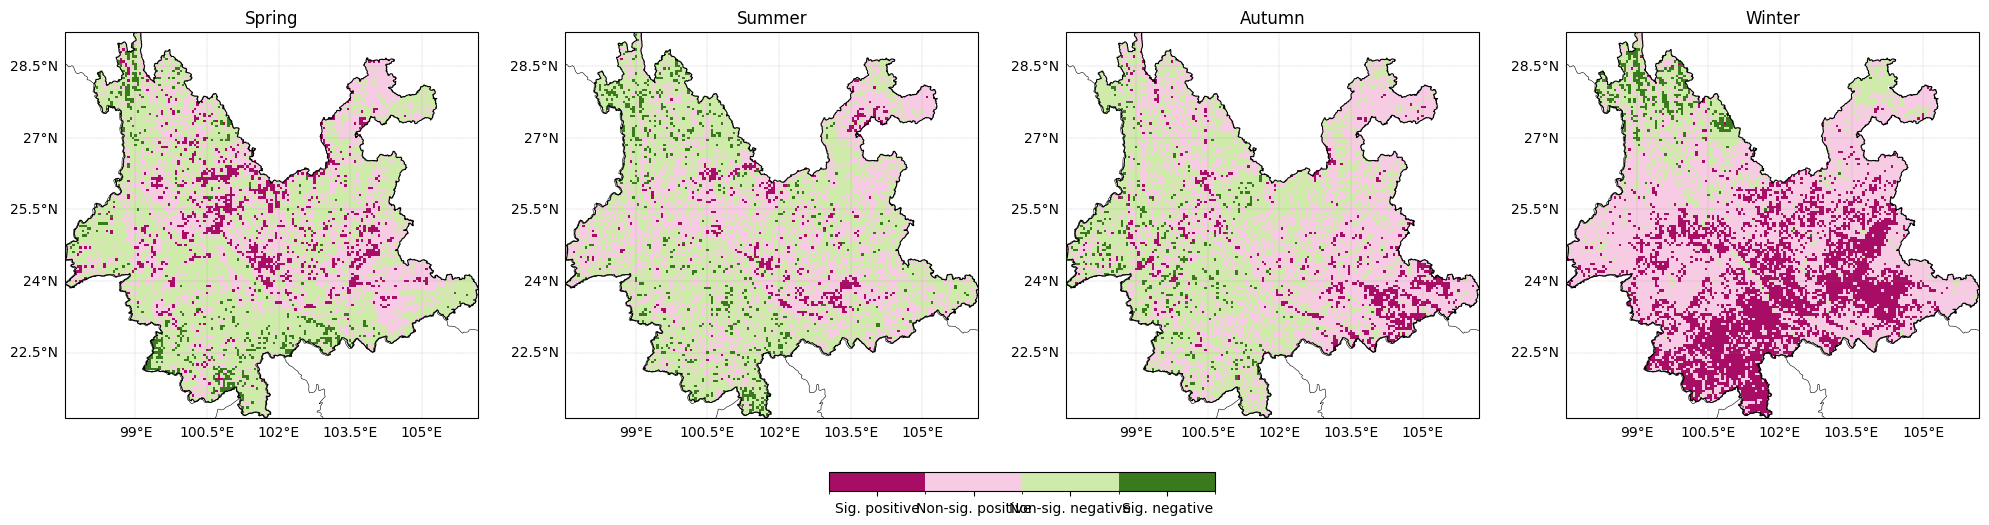

In [65]:
!pip install -q rioxarray

from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import rioxarray

project_dir = Path('/content/drive/MyDrive/Drought-monitoring-and-assessment')
corr_dir = project_dir / "output/corr_xy"
shp_fn = "/content/drive/MyDrive/gis/boua_s.shp"
x_name="sai"
seasons = ["spring", "summer", "autumn", "winter"]
titles = ["Spring", "Summer", "Autumn", "Winter"]

gdf = gpd.read_file(shp_fn).to_crs("EPSG:4326")

# 4级离散色带
# 1 显著正相关
# 2 不显著正相关
# 3 不显著负相关
# 4 显著负相关
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

base = plt.cm.PiYG
cmap = ListedColormap([
    base(0.05),  # 深洋红
    base(0.35),  # 浅粉
    base(0.65),  # 浅绿
    base(0.95)   # 深绿
])

norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

fig, axes = plt.subplots(
    nrows=1, ncols=4,
    figsize=(20, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

for ax, season, title in zip(axes, seasons, titles):
    fn = corr_dir / f"corr_{x_name}_spei_{season}.nc"
    ds = xr.open_dataset(fn)

    ds = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
    ds = ds.rio.write_crs("EPSG:4326")
    ds = ds.rio.clip(gdf.geometry, gdf.crs, drop=True)

    r = ds["r"]
    p = ds["p"]

    # 4类分级
    cls = xr.full_like(r, np.nan)

    cls = xr.where((r > 0) & (p < 0.05), 1, cls)   # 显著正相关
    cls = xr.where((r > 0) & (p >= 0.05), 2, cls)  # 不显著正相关
    cls = xr.where((r < 0) & (p >= 0.05), 3, cls)  # 不显著负相关
    cls = xr.where((r < 0) & (p < 0.05), 4, cls)   # 显著负相关

    lon = cls["lon"]
    lat = cls["lat"]

    im = ax.pcolormesh(
        lon, lat, cls,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    ax.add_geometries(
        gdf.geometry,
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )

    ax.set_title(title, fontsize=12)
    ax.coastlines(resolution="110m", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False

# 公共图例
cbar = fig.colorbar(
    im, ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    ticks=[1, 2, 3, 4]
)
cbar.ax.set_xticklabels([
    "Sig. positive",
    "Non-sig. positive",
    "Non-sig. negative",
    "Sig. negative"
])

plt.show()

In [49]:
shp_fn="/content/drive/MyDrive/gis/boua_s.shp"

<xarray.Dataset> Size: 8MB
Dimensions:      (time: 25, lat: 201, lon: 201)
Coordinates:
  * time         (time) datetime64[ns] 200B 2001-01-01 2002-01-01 ... 2025-01-01
  * lat          (lat) float64 2kB 20.0 20.05 20.1 20.15 ... 29.9 29.95 30.0
  * lon          (lon) float64 2kB 97.0 97.05 97.1 97.15 ... 106.9 106.9 107.0
Data variables:
    spatial_ref  (time) float64 200B ...
    ndvi         (time, lat, lon) float64 8MB ...